Company Size Mapping:
L -> 0
M -> 1
S -> 2
Dataset saved at: E:\ML ASSIGNMENT 2\RQ6_company_size_dataset.csv
           Model           MAE           MSE          RMSE  R2 Score
0  Random Forest  48923.550905  3.849982e+09  62048.225273  0.039269
  company_size     Avg_Salary  Avg_Benefits  Count
0            L  138466.265186      7.479870   5087
1            M  118876.322803      7.518206   4938
2            S  108239.176080      7.501126   4975


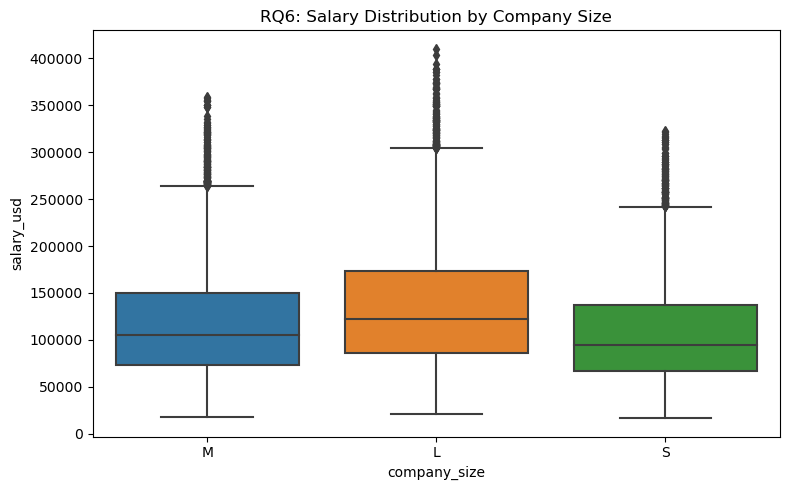

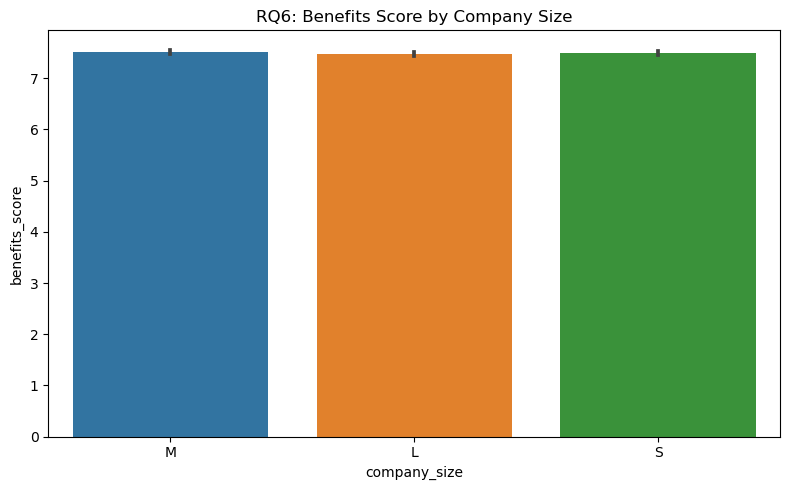

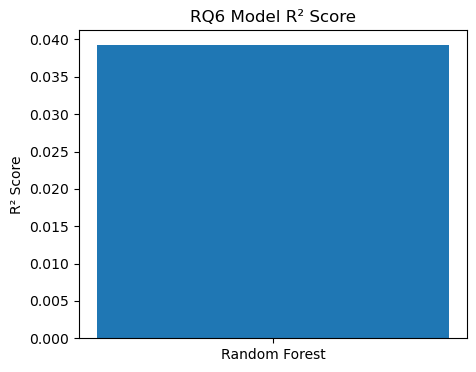


Feature Importance:
                Feature  Importance
0  company_size_encoded         1.0

RQ6 CONCLUSION
Company size has weak influence on compensation packages.


In [1]:

# RQ6: DOES COMPANY SIZE INFLUENCE SALARY?


import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

file_path = "ai_job_dataset1.csv"
df = pd.read_csv(file_path)

data = df[[
    "company_size",
    "salary_usd",
    "benefits_score"
]].dropna()

le = LabelEncoder()
data["company_size_encoded"] = le.fit_transform(data["company_size"])

print("Company Size Mapping:")
for i, cls in enumerate(le.classes_):
    print(cls, "->", i)

model_path = "models"
table_path = "tables"

os.makedirs(model_path, exist_ok=True)
os.makedirs(table_path, exist_ok=True)

save_path = r"E:\ML ASSIGNMENT 2\RQ6_company_size_dataset.csv"
data.to_csv(save_path, index=False)

print("Dataset saved at:", save_path)

X = data[["company_size_encoded"]]
y = data["salary_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

results_df = pd.DataFrame([{
    "Model": "Random Forest",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r2
}])

# Save table
results_df.to_csv(f"{table_path}/RQ6_model_results.csv", index=False)

print(results_df)

table = data.groupby("company_size").agg(
    Avg_Salary=("salary_usd", "mean"),
    Avg_Benefits=("benefits_score", "mean"),
    Count=("salary_usd", "count")
).reset_index()

table.to_csv(f"{table_path}/RQ6_company_size_summary.csv", index=False)

print(table)

plt.figure(figsize=(8,5))
sns.boxplot(x="company_size", y="salary_usd", data=data)

plt.title("RQ6: Salary Distribution by Company Size")
plt.tight_layout()

plt.savefig(f"{model_path}/RQ6_salary_boxplot.png")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="company_size", y="benefits_score", data=data)

plt.title("RQ6: Benefits Score by Company Size")
plt.tight_layout()

plt.savefig(f"{model_path}/RQ6_benefits_barplot.png")
plt.show()

plt.figure(figsize=(5,4))
plt.bar(["Random Forest"], [r2])
plt.title("RQ6 Model R² Score")
plt.ylabel("R² Score")

plt.savefig(f"{model_path}/RQ6_model_r2.png")
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.to_csv(f"{table_path}/RQ6_feature_importance.csv", index=False)

print("\nFeature Importance:")
print(importance)
int("\n===================================")
print("RQ6 CONCLUSION")
print("===================================")

if r2 > 0.5:
    print("Company size has a measurable influence on compensation packages.")
else:
    print("Company size has weak influence on compensation packages.")